## preprocessing file 


In [ ]:
from preprocess_TCGA import preprocess_data
import pandas as pd


# load data expression and labels 
expr = pd.read_parquet("Downloads/mRNA_coding.omics.parquet")
label=pd.read_parquet("Downloads/label.parquet")
print('show expression data and shape',expr.head(), expr.shape)
print('show data labels and shape ',label.head(),label.shape)
outputdir=''
preprocess_data(expr, label, outputdir)



In [2]:
import pandas as pd
import os
import torch
import numpy as np
outputdir=''

In [3]:
df_x_test=pd.read_csv(os.path.join(outputdir,'comb_x_val.csv'))
df_y_test=pd.read_csv(os.path.join(outputdir,'comb_y_val.csv'))
df_x_tune=pd.read_csv(os.path.join(outputdir,'comb_x_te.csv'))
df_y_tune=pd.read_csv(os.path.join(outputdir,'comb_y_te.csv'))

## load datasets

In [ ]:
from baseline_mlp import run_baseline_experiment, BaselineConfig

cfg = BaselineConfig(
    proportions=np.linspace(0.1, 1.0, 10),
    runs=5,
    epochs=10,
    batch_size=32,
    lr=1e-3,
    dropout_rate=0.1,
    seed=42,
    save_checkpoints=True,
)

results_df, best_acc = run_baseline_experiment(
    df_x_tune=df_x_tune,
    df_y_tune=df_y_tune,
    df_x_test=df_x_test,
    df_y_test=df_y_test,
    output_dir=outputdir,
    cfg=cfg
)
print("Baseline results:")

## Compute pathways 

In [5]:
from pathway_scores import compute_ssgsea_scores, SSGSEAConfig

drop_cols = [
    "ENSG00000169789",
    "ENSG00000139656",
    "ENSG00000148362",
    "ENSG00000168078",
    "ENSG00000189144",
]

cfg = SSGSEAConfig(
    library="KEGG_2021_Human",   # or "Hallmark_2020", "MSigDB_C2_2023"
    batch_size=500,
    score_type="NES",
    processes=4,
    sample_norm=False
)

pathway_scores = compute_ssgsea_scores(
    df_x=df_x_tune,  # samples x genes (Ensembl columns)
    out_path=os.path.join(outputdir,"kegg_ssgsea_scores_finetune.parquet")
    drop_cols=drop_cols,
    cfg=cfg
)

pathway_scores.head()


SyntaxError: invalid syntax (153410497.py, line 22)

In [40]:
from pretraining import pretrain_autoencoder

X=pd.read_parquet(os.path.join(outputdir,"comb_x_tr.parquet"))
Yp=pd.read_parquet(os.path.join(outputdir,"kegg_ssgsea_scores_finetune.parquet"))

FileNotFoundError: [Errno 2] No such file or directory: '/kegg_ssgsea_scores_finetune.parquet'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
Yp.astype('float32')


,Name,ABC transporters,AGE-RAGE signaling pathway in diabetic complications,AMPK signaling pathway,Acute myeloid leukemia,Adherens junction,Adipocytokine signaling pathway,Adrenergic signaling in cardiomyocytes,African trypanosomiasis,"Alanine, aspartate and glutamate metabolism",...,Vitamin digestion and absorption,Wnt signaling pathway,Yersinia infection,alpha-Linolenic acid metabolism,beta-Alanine metabolism,cAMP signaling pathway,cGMP-PKG signaling pathway,mRNA surveillance pathway,mTOR signaling pathway,p53 signaling pathway
0,0.0,-0.034176,0.079277,0.131229,0.079022,0.183098,0.044217,0.022002,-0.159568,-0.088260,...,-0.162528,0.101042,0.186746,-0.061493,-0.087831,-0.054654,0.016916,0.357486,0.152572,0.235092
1,1.0,0.019507,0.063708,0.129373,0.061735,0.136309,0.088386,0.016218,-0.107731,0.051999,...,-0.012422,0.038493,0.209187,-0.047766,0.122994,-0.050435,0.006508,0.235909,0.169807,0.077741
2,10.0,-0.007501,0.064299,0.143431,0.109120,0.198309,0.094977,0.018565,0.042620,-0.098445,...,-0.084834,0.072486,0.266125,-0.166014,-0.021999,-0.029517,0.013156,0.269391,0.157353,0.166605
3,100.0,-0.041444,0.160789,0.137624,0.188353,0.176695,0.104774,0.052667,0.038988,-0.110256,...,-0.039997,0.046234,0.313868,-0.151315,0.007894,-0.009864,0.111783,0.244978,0.143408,0.123040
4,101.0,-0.069961,0.155149,0.128780,0.146246,0.207674,0.094254,0.028970,0.013926,-0.170970,...,-0.135502,0.095457,0.279579,-0.086961,-0.076577,-0.005245,0.110247,0.272657,0.142293,0.110762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6539,6539.0,-0.064934,0.089548,0.143794,0.100945,0.176452,0.103984,0.024817,-0.160219,-0.095819,...,-0.068727,0.095783,0.208234,-0.089437,0.039131,-0.040796,0.014208,0.290976,0.171373,0.042365
6540,6540.0,-0.064508,0.063028,0.166207,0.151613,0.154479,0.105176,-0.004095,-0.023526,0.002261,...,-0.032650,0.071510,0.237073,-0.083729,0.044858,-0.057325,0.002786,0.330666,0.144788,0.223092
6541,6541.0,-0.094137,0.059238,0.143633,0.144957,0.157526,0.062706,0.001094,-0.121138,-0.027147,...,-0.045675,0.118677,0.191044,-0.206210,-0.091407,-0.049776,0.038467,0.345143,0.181347,0.125021
6542,6542.0,-0.080458,0.112573,0.131027,0.206737,0.187146,0.126412,0.002988,0.041257,-0.029215,...,-0.062491,0.099993,0.302354,-0.113178,-0.055832,-0.048870,0.010847,0.344316,0.188534,0.161153


In [ ]:
# Suppose:
# X:   gene expression matrix (cells x genes)
# Yp:  computed pathway profiles (cells x pathways)

# Convert pandas DataFrames to numpy arrays and then to tensors
X_tensor = torch.tensor(X.values, dtype=torch.float32)
Yp_tensor = torch.tensor(Yp.values, dtype=torch.float32)

model = pretrain_autoencoder(
    X_tensor,
    Yp_tensor,
    input_dim=X_tensor.shape[1],
    pathway_dim=Yp_tensor.shape[1],
    latent_dim=256,
    epochs=100
)


Epoch 1/100, Loss = 16006.09544
Epoch 2/100, Loss = 11770.71372
Epoch 3/100, Loss = 11740.10826
Epoch 4/100, Loss = 11449.30744
Epoch 5/100, Loss = 11411.67547
Epoch 6/100, Loss = 10823.07412
Epoch 7/100, Loss = 10546.12436
Epoch 8/100, Loss = 10331.07718
Epoch 9/100, Loss = 9306.05416
Epoch 10/100, Loss = 9267.81203
Epoch 11/100, Loss = 9431.11106
Epoch 12/100, Loss = 7298.26937
Epoch 13/100, Loss = 7860.98236
Epoch 14/100, Loss = 6408.51744
Epoch 15/100, Loss = 6239.79791
Epoch 16/100, Loss = 5788.32584
Epoch 17/100, Loss = 5051.57515
Epoch 18/100, Loss = 6103.30994
Epoch 19/100, Loss = 5077.03673
Epoch 20/100, Loss = 4575.82756
Epoch 21/100, Loss = 4470.60875
Epoch 22/100, Loss = 4096.88944
Epoch 23/100, Loss = 3891.08409
Epoch 24/100, Loss = 4136.41876
Epoch 25/100, Loss = 3871.43018
Epoch 26/100, Loss = 3276.15199
Epoch 27/100, Loss = 3771.67324
Epoch 28/100, Loss = 3292.60421
Epoch 29/100, Loss = 3221.37717
Epoch 30/100, Loss = 3058.98483
Epoch 31/100, Loss = 2821.46986
Epoch 32/

##pretrain

## Save auto-encoder

In [ ]:

import importlib
import pretraining
importlib.reload(pretraining)
from pretraining import load_pretrained_encoder  # Absolute import
from pretraining import save_pretrained_model

In [ ]:
path = os.path.join(outputdir,"ssl_pretrained")

In [ ]:

config = {
    "input_dim": X.shape[1],
    "pathway_dim": Yp.shape[1],
    "latent_dim": 256
}

save_pretrained_model(model.encoder, config, path)

encoder, config = load_pretrained_encoder(path)

encoder.eval() 
encoder, cfg = load_pretrained_encoder(path)
encoder.eval()

z = encoder(torch.randn(1, cfg["input_dim"]))
print(z.shape)


[OK] Saved encoder + config inside /ssl_pretrained
[OK] Loaded pretrained encoder from /ssl_pretrained
[OK] Loaded pretrained encoder from /ssl_pretrained
torch.Size([1, 256])


In [ ]:
import finetuning
importlib.reload(finetuning)
from finetuning import run_multiproportion_finetuning
from finetuning import finetune_single_run

In [ ]:
encoder, enc_config = load_pretrained_encoder(path)

latent_dim = enc_config["latent_dim"]
input_dim = enc_config["input_dim"]
num_classes = len(torch.unique(y_full))


result_single=finetune_single_run(
        encoder, X_full, y_full, X_test, y_test,
        latent_dim, num_classes,
        freeze_encoder=True,
        epochs=20,
        batch_size=32,
        lr=1e-3)


[OK] Loaded pretrained encoder from /ssl_pretrained


In [ ]:
# Load SSL encoder
encoder, enc_config = load_pretrained_encoder(path)

latent_dim = enc_config["latent_dim"]
input_dim = enc_config["input_dim"]
num_classes = len(torch.unique(y_full))


# Run multi-proportion fine-tuning
results = run_multiproportion_finetuning(
    encoder,
    X_full, y_full,
    X_test, y_test,
    latent_dim=latent_dim,
    num_classes=num_classes,
    save_dir=path,
    proportions=np.linspace(0.1, 1.0, 10),
    runs=5,
    freeze_encoder=False    # Set True for linear probe
)


[OK] Loaded pretrained encoder from /ssl_pretrained

===== Fine-tuning on 10% data =====
 Run 1: acc=0.5143
 Run 2: acc=0.7076
 Run 3: acc=0.7725
 Run 4: acc=0.8310
 Run 5: acc=0.7775

===== Fine-tuning on 20% data =====
 Run 1: acc=0.8509
 Run 2: acc=0.8588
 Run 3: acc=0.8773
 Run 4: acc=0.8859
 Run 5: acc=0.8887

===== Fine-tuning on 30% data =====
 Run 1: acc=0.9030
 Run 2: acc=0.9101
 Run 3: acc=0.9215
 Run 4: acc=0.9151
 Run 5: acc=0.8652

===== Fine-tuning on 40% data =====
 Run 1: acc=0.9066
 Run 2: acc=0.9151
 Run 3: acc=0.9230
 Run 4: acc=0.9158
 Run 5: acc=0.9265

===== Fine-tuning on 50% data =====
 Run 1: acc=0.9308
 Run 2: acc=0.9208
 Run 3: acc=0.9272
 Run 4: acc=0.9258
 Run 5: acc=0.9301

===== Fine-tuning on 60% data =====
 Run 1: acc=0.9237
 Run 2: acc=0.9244
 Run 3: acc=0.9244
 Run 4: acc=0.9330
 Run 5: acc=0.9358

===== Fine-tuning on 70% data =====
 Run 1: acc=0.9315
 Run 2: acc=0.9287
 Run 3: acc=0.9315
 Run 4: acc=0.9280
 Run 5: acc=0.9365

===== Fine-tuning on 80

## unfrozen autoencoder

In [ ]:
from finetuning_unfrozen import run_multiproportion_finetuning_unfrozen
results_unf = run_multiproportion_finetuning_unfrozen(
    encoder,
    X_full, y_full,
    X_test, y_test,
    latent_dim=latent_dim,
    num_classes=num_classes,
    save_dir=path,
    proportions=np.linspace(0.1, 1.0, 10),
    runs=5,
    freeze_encoder=False    # Set True for linear probe
)



===== Fine-tuning on 10% data =====
 Run 1: acc=0.9344
 Run 2: acc=0.9337
 Run 3: acc=0.9244
 Run 4: acc=0.9265
 Run 5: acc=0.9187

===== Fine-tuning on 20% data =====
 Run 1: acc=0.9337
 Run 2: acc=0.9287
 Run 3: acc=0.9194
 Run 4: acc=0.9330
 Run 5: acc=0.9330

===== Fine-tuning on 30% data =====
 Run 1: acc=0.9372
 Run 2: acc=0.9351
 Run 3: acc=0.9379
 Run 4: acc=0.9408
 Run 5: acc=0.9344

===== Fine-tuning on 40% data =====
 Run 1: acc=0.9265
 Run 2: acc=0.9358
 Run 3: acc=0.9415
 Run 4: acc=0.9337
 Run 5: acc=0.9351

===== Fine-tuning on 50% data =====
 Run 1: acc=0.9351
 Run 2: acc=0.9322
 Run 3: acc=0.9337
 Run 4: acc=0.9322
 Run 5: acc=0.9351

===== Fine-tuning on 60% data =====
 Run 1: acc=0.9322
 Run 2: acc=0.9330
 Run 3: acc=0.9280
 Run 4: acc=0.9265
 Run 5: acc=0.9294

===== Fine-tuning on 70% data =====
 Run 1: acc=0.9365
 Run 2: acc=0.9351
 Run 3: acc=0.9315
 Run 4: acc=0.9415
 Run 5: acc=0.9415

===== Fine-tuning on 80% data =====
 Run 1: acc=0.9258
 Run 2: acc=0.9272
 

## Visulaize performance

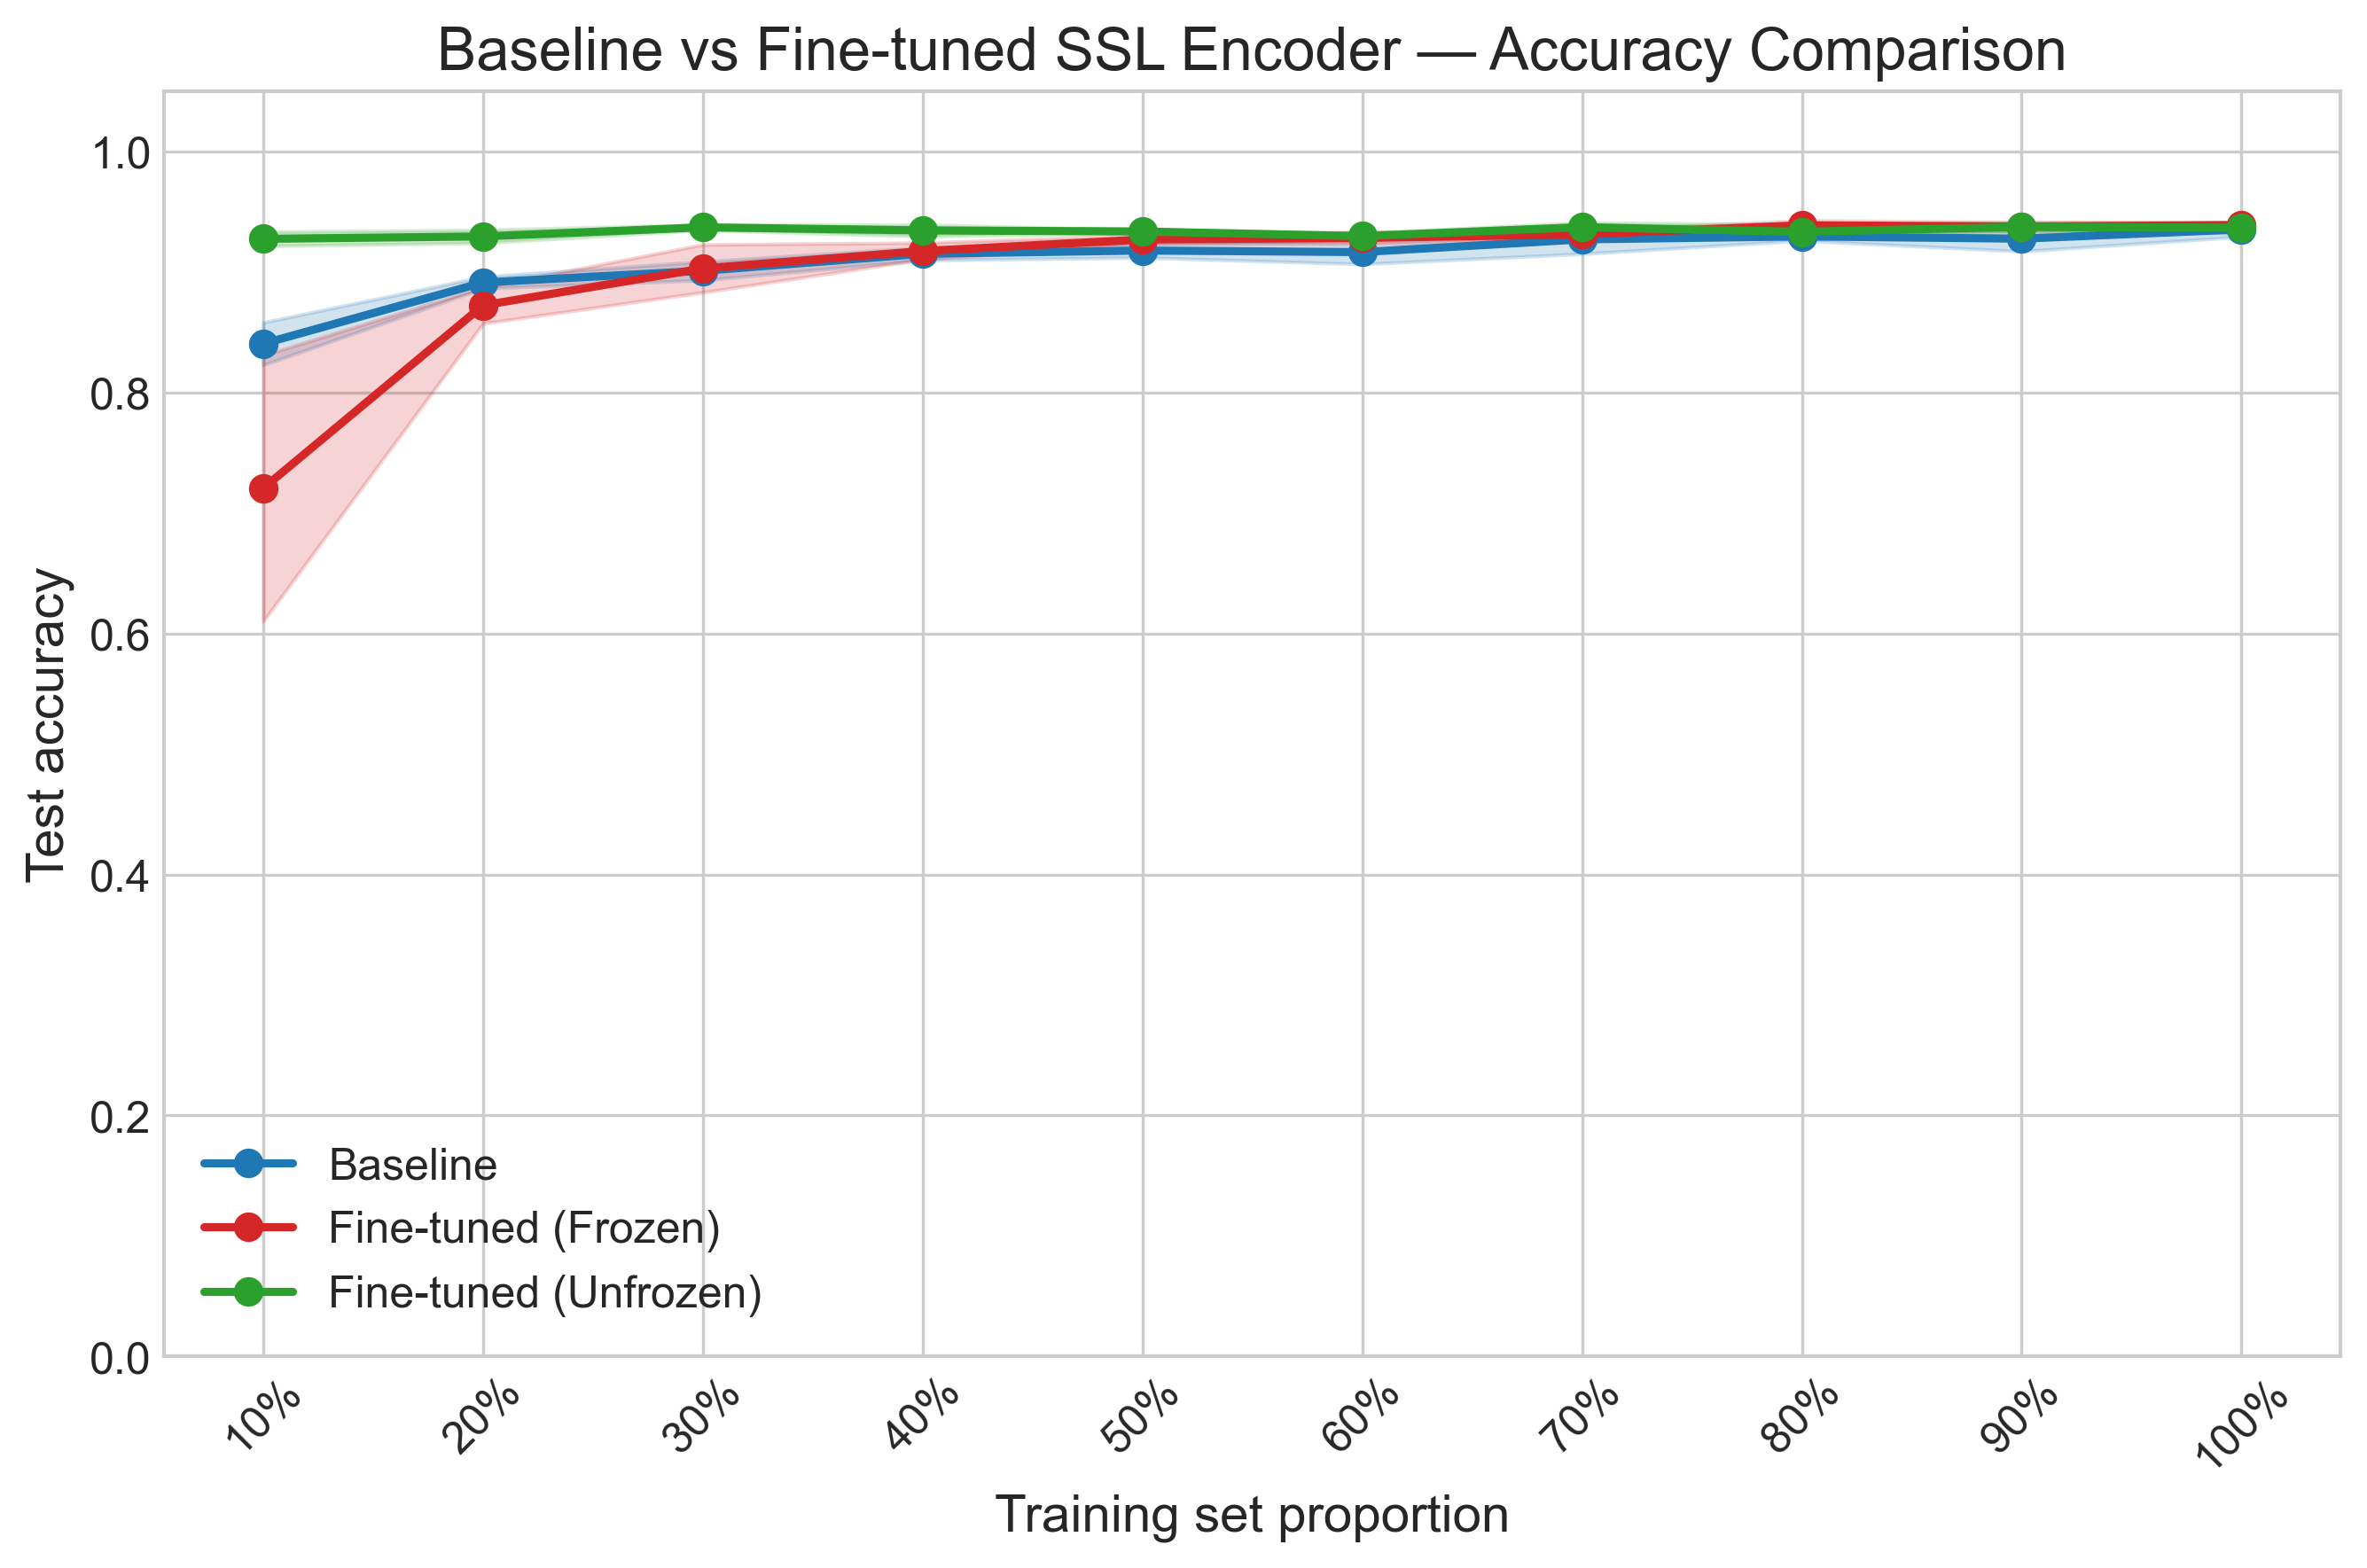

In [ ]:


from visualise_res import visualize_results
paths = {
    "Baseline": "baseline_results.csv",
    "Fine-tuned (Frozen)": "/ssl_pretrained/finetune_results.csv",
    # Add this only if you have unfrozen encoder results:
     "Fine-tuned (Unfrozen)": "/ssl_pretrained/finetune_results_unfrozen.csv"
}
visualize_results(paths)